<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2024-2/Sesiones/Sesion_12_Desicion_Tree_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Algoritmo CART (classification and regresion tree)

Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de decisión secuencial.

-  https://www.nature.com/articles/nmeth.4370
- Ref https://www.youtube.com/watch?v=kqaLlte6P6o&ab_channel=CodificandoBits
- Hand on Machine leargning




In [1]:
# referencias
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pylab as plt

Dado un conjunto de características se establece una condición que realiza
una partición binaria de los datos a clasificar repitiendo hasta encontrar
particiones lo más homogeneas posibles.




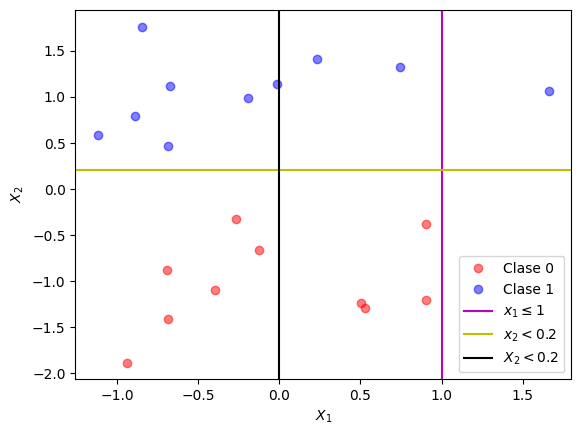

In [4]:
X0, y0 = make_classification(n_samples=20,
    n_features=2, n_redundant=0, n_informative=1, random_state=1,
    n_clusters_per_class=1)

x = np.arange(-2,3,1)
x_,y_ = np.meshgrid(x,x)

fig, ax = plt.subplots()
ax.plot(X0[:,0][y0==0],X0[:,1][y0==0],"ro", alpha=0.5, label='Clase 0')
ax.plot(X0[:,0][y0==1],X0[:,1][y0==1],"bo", alpha=0.5, label='Clase 1')
#ax.plot(x_,y_,"k.")

ax.axvline(x = 1, color = 'm', label=r"$x_1 \leq 1$")
ax.axhline(y = 0.2, color = 'y', label=r"$x_2<0.2$")
ax.axvline(x = 0.0, color = 'k', label=r"$X_2<0.2$")
#plt.legend(loc=3)
plt.xlabel("$X_1$")
plt.ylabel("$X_2$")
plt.legend()
plt.savefig("3.png")

## Índice de Gini

El índice o impureza de Gini en un árbol de decisión clasificador es una medida de la impureza o heterogeneidad de un nodo o una partición de datos. El índice de Gini varía entre $0$ y $1$:

* $0$ significa que el nodo o la partición es puro (todas las muestras pertenecen a una sola clase).

* $1$ significa que el nodo o la partición es impuro (las muestras están distribuidas uniformemente entre todas las clases).


La impureza de Gini mide la frecuencia con la que se clasifica incorrectamente un atributo elegido al azar. Cuando se evalúa usando la impureza de Gini, un valor más bajo es más ideal.

**Para clasificación binaria:**

$$G = 1 - (P_{C_1})^2 - (P_{C_2})^2$$

$P_{C_1}$: Probablidad categoria 1

$P_{C_2}$: Probablidad categoria 2

¿* $G=0$ nodos puros, datos que pertenecen a una sola categoría.

* $G>0$ son nodos con impurezas, con más de una categoría.

\
**Gráfico:**

La partición púrpura y amarilla del gráfico anterior representan nodos puros.

Mientras que la línea negra define:

* Lado izquierdo:

  - 7 puntos son de color azul.

  - 6 puntos de color rojo.

  $G_{left} = 1 - (7/13)^{2} - (6/13)^{2}$

  La ponderación viene dada por: $\quad m_{left} = (7/20+7/20)=7/10$

* Lado derecho:

    - $G_{right} = 1-(3/7)^{2}-(4/7)^{2}$

    - $m_{right} = (3/20+4/20) = 7/20$


La funcion de coste, asocida al nodo padre:

$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right} $

\
## Entropía de Gini

La entropía es un concepto que se deriva de la teoría de la información, que mide la impureza de los valores de la muestra.


$$H=-\sum_{k=1\\ p_{ik \neq 0}}^{n} p_{ij}\log_2(p_{ik})$$


Los valores de entropía pueden estar entre 0 y 1.

* Si todas las muestras en el conjunto de datos, S, pertenecen a una clase, entonces la entropía será igual a cero

\
## Algoritmo
1. Calcular todos los posibles condiciones.
2. Calcular los indices de Gini.
3. Encontrar la funcion de coste
4. Escoger la menor funcion de coste
5. Repetir.


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
import graphviz
#from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
import numpy as np
from sklearn import tree

In [6]:
# Libraries for draw contours
def make_meshgrid(x, y, h=0.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_contoursExact(ax, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

In [7]:
iris = load_iris()

# Estratificación de los datos
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target,\
                                                    test_size=0.33, random_state=42)

## Clase `DecisionTreeClassifier`:

Entrena un árbol de decisión que intenta segmentar los datos en nodos puros (o casi puros) con base en la distribución de las clases, siguiendo un criterio de impureza (como Gini o Entropía).

**Parámetros:**

* `criterion (str, 'gini')`: Métrica de impureza.

  `['gini', 'entropy', 'log_loss']`

* `splitter (str, 'best')`: Estrategia de división en cada nodo.

  * 'best': evalúa todas las posibles divisiones y elige la que más reduce la impureza.

  * 'random': selecciona una división de entre varias opciones aleatorias.

* `max_depth (int, None)`: Profundidad máxima del árbol.

  `None`: cada rama se sigue expandiendo hasta que todos los nodos sean puros o hasta agotar los datos (ojo con sobrefitear)

* `min_samples_split (int, float para %, 2)`: Mínimo número de muestras para dividir un nodo.

* `max_features (int, float, str, None)`: Número máximo de características a considerar cuando se busca la mejor división.

  * `None`: Usar todas las características.

  * `'sqrt'`: $\sqrt{n_{features}}$

  * `'log2'`, entero o fracción.


\
**Atributos:**

* feature_importances_: array de forma (n_features,) que muestra la importancia de cada característica en el árbol (basada en la reducción de impureza a través de las divisiones).

* `tree_`: objeto interno que contiene la estructura real del árbol (nodos, umbrales, etc.).

* `n_features_in_`: número de características usadas en el entrenamiento.

* `n_classes_`: número de clases (para clasificación).


\
**Métodos:**

* `fit(X,y), predict(X), predict_proba(X), score(X,y) -> accuracy`

* `decision_path(X)`: Devuelve, para cada muestra, la ruta (secuencia de nodos) seguida a través del árbol.

* `apply(X)`: Indica el nodo hijo al que llega cada muestra de X tras recorrer el árbol.

\
**Observación:**

Interoperabilidad: Los árboles de decisión pueden usarse en métodos como Bagging (por ejemplo, `RandomForestClassifier`) o Boosting (por ejemplo, `GradientBoostingClassifier`).




In [8]:
clf = DecisionTreeClassifier(max_depth=100)
clf.fit(X_train, y_train)

print('Exactitud del modelo (accuracy)')
print(f"\tDatos de prueba: {clf.score(X_test, y_test)}")
print(f"\tDatos de entrenamiento: {clf.score(X_train, y_train)}")

Exactitud del modelo (accuracy)
	Datos de prueba: 0.98
	Datos de entrenamiento: 1.0


[Forma de guardar el árbol de decisión](https://scikit-learn.org/stable/odules/generated/sklearn.tree.export_graphviz.html
)

In [12]:
# guardar gráfico, poner archivo_salida con el nombre
arbol = tree.export_graphviz(clf, out_file='tree_one.txt',
                    class_names = iris.target_names,\
                    feature_names = iris.feature_names,\
                    impurity=False, filled=True)
!ls

3.png  sample_data  tree_one  tree_one.png  tree_one.txt


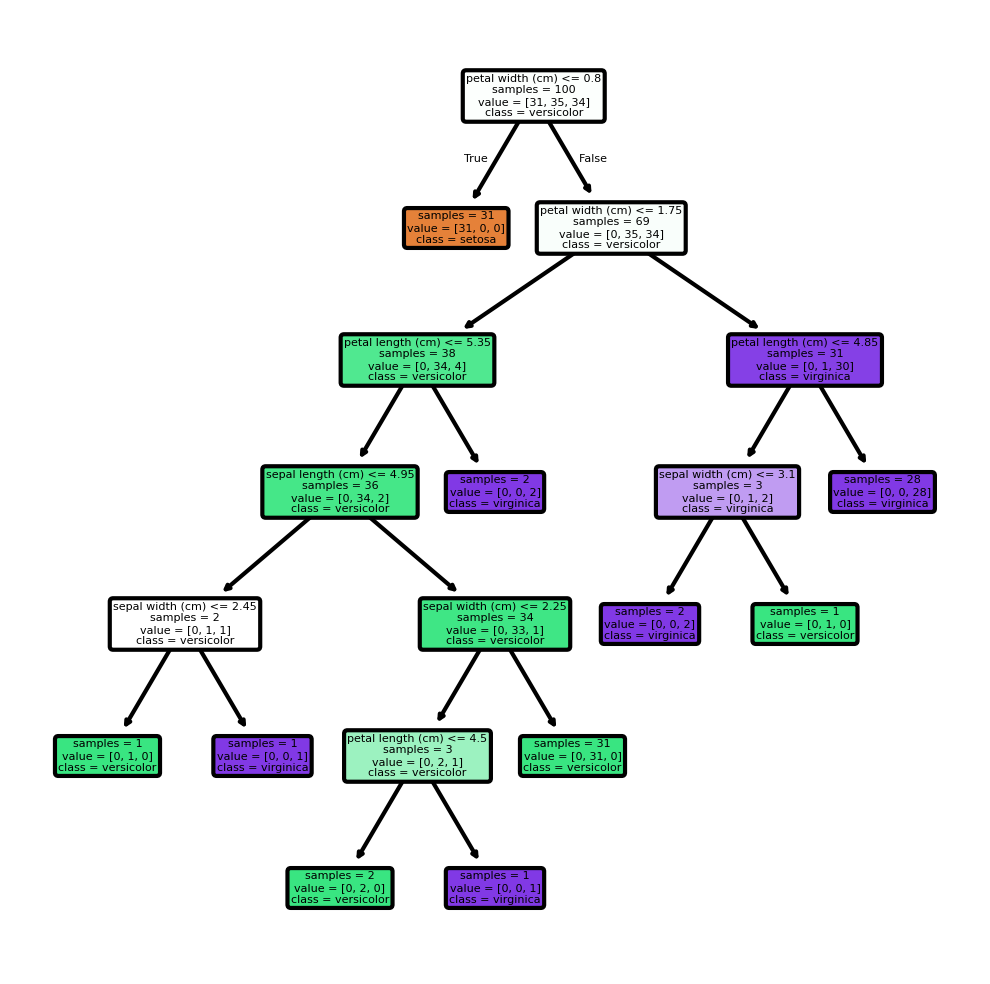

In [13]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(4,4), dpi=300)

graph = tree.plot_tree(clf, class_names=iris.target_names,\
              feature_names=iris.feature_names,\
              impurity=False, filled=True, rounded=True)

## Importancia de las características

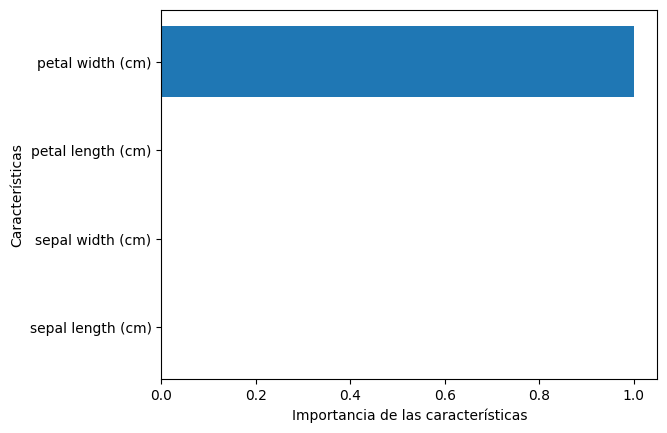

In [ ]:
caract = iris.data.shape[1]
plt.barh(range(caract), clf.feature_importances_)
plt.yticks(np.arange(caract),iris.feature_names)
plt.xlabel('Importancia de las características')
plt.ylabel('Características')
plt.show()

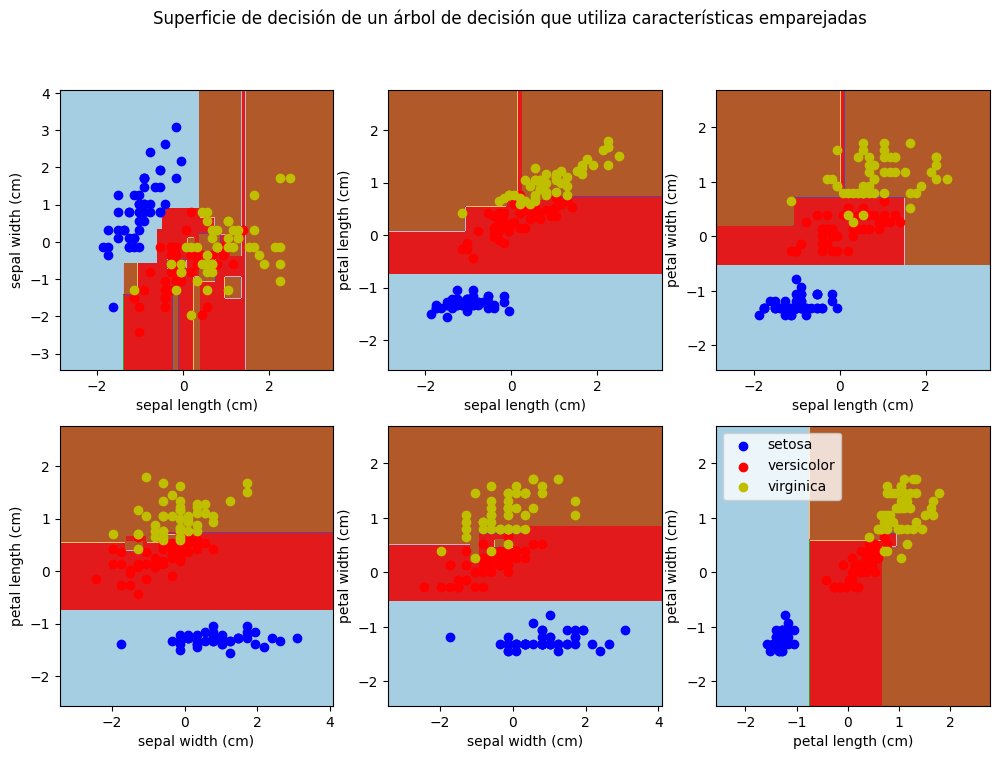

In [21]:
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Parameters
n_classes = 3
plot_colors = "bry"
plot_step = 0.02

# Load data
iris = load_iris()

'''
  Relacionamos pares de características para observar la clasificación

  El código recorre todas las combinaciones de pares de features del Iris dataset,
  entrena un árbol de decisión con solo esas dos características y dibuja la frontera
  de decisión resultante junto con las muestras originales.
'''
fig = plt.figure(figsize=(12, 8))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],     # Combinamos las características
                                [1, 2], [1, 3], [2, 3]]):
    # Sólo tomamos las dos características correspondientes (columnas)
    # print(f'Par {pairidx+1}:{pair}')
    X = iris.data[:, pair]
    y = iris.target

    # Barajamos la cantidad de datos
    idx = np.arange(X.shape[0])
    np.random.seed(13)        # Mantenemos la misma secuencia aleatoria
    np.random.shuffle(idx)    # Baraja aleatoriamente los elementos del arreglo idx
    X = X[idx]
    y = y[idx]

    # Normalizamos las características
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X-mean)/std

    # Entrenamos el árbol
    clf = DecisionTreeClassifier().fit(X, y)

    # --------------- Trazamos el límite de decisión ---------------
    plt.subplot(2, 3, pairidx + 1)

    # Generamos una malla
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    # Clasificamos cada punto de la malla
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # Graficamos los puntos de entrenamiento
    for c, color in zip(range(n_classes), plot_colors):   # zip -> combina dos iterables
        idclass = np.where(y == c)    # índices donde y==c
        plt.scatter(X[idclass, 0], X[idclass, 1], c=color, label=iris.target_names[c])
                    # cmap=plt.cm.Paired)

    plt.axis("tight")

plt.suptitle("Superficie de decisión de un árbol de decisión que utiliza características emparejadas")
plt.legend()
plt.show()
fig.tight_layout()